<a href="https://colab.research.google.com/github/syeonsu500-cell/Dlseltk500.io/blob/main/3%EB%B2%88_%ED%8C%80_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  [Step 1] 기획 및 데이터 수집
## 아이디어 발굴 : "전동 킥보드, 어디에 주차해야 가장 안전하고 견인 위험이 낮을까?"

# [Step 2-1] 데이터 탐색 :
## 1. 서울시 전동킥보드 견인 현황

## 데이터 불러오기 및 기초 통계 확인

### `df_parking` 데이터프레임 로드
### [프롬프트]
**'서울시 전동킥보드 주차구역 현황.csv' 파일을 읽어 `df_parking` 데이터프레임을 생성한다.**    
  
(-> 이 데이터프레임은 이후 분석 및 시각화 작업의 기반이 될 것임.)

In [ ]:
import pandas as pd

file_path_parking = '서울시 전동킥보드 주차구역 현황.csv'

try:
    df_parking = pd.read_csv(file_path_parking, encoding='cp949', engine='python')
    print(f"'{file_path_parking}' 파일 로드 성공!")
    print("\ndf_parking 데이터프레임의 첫 5행:")
    display(df_parking.d())
except FileNotFoundError:
    print(f"오류: '{file_path_parking}' 파일을 찾을 수 없습니다. 파일을 Colab 환경에 업로드해주세요.")
except pd.errors.ParserError as e:
    print(f"오류: '{file_path_parking}' 파일을 파싱하는 데 문제가 발생했습니다: {e}")
    print("엔진을 'python'으로 변경하여 재시도합니다.")
    try:
        df_parking = pd.read_csv(file_path_parking, encoding='cp949', engine='python')
        print(f"'{file_path_parking}' 파일 재로드 성공!")
        print("\ndf_parking 데이터프레임의 첫 5행:")
        display(df_parking.head())
    except Exception as e_inner:
        print(f"재시도 실패: {e_inner}")
except Exception as e:
    print(f"파일 로드 중 알 수 없는 오류 발생: {e}")



'서울시 전동킥보드 주차구역 현황.csv' 파일 로드 성공!

df_parking 데이터프레임의 첫 5행:


,순번,시군구명,주소,상세위치,거치대 유무
0,1,종로구,팔판동 115-63,청와대 춘추문 맞은편,Y
1,2,종로구,연건동 218-1,KT 광화문 혜화지사 앞,Y
2,3,종로구,연건동 178-3,홍익대학교 대학로 맞은편,Y
3,4,종로구,동승동 1-24,대학로 마로니에 공원 앞,Y
4,5,종로구,와룡동 75-4,연악사 맞은편,Y


In [ ]:
import pandas as pd

file_path_parking = '서울시 전동킥보드 주차구역 현황.csv'

try:
    df_parking = pd.read_csv(file_path_parking, encoding='cp949', engine='python')
    print(f"'{file_path_parking}' 파일 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{file_path_parking}' 파일을 찾을 수 없습니다. 파일을 Colab 환경에 업로드해주세요.")
    # Colab에서 파일을 업로드하려면 다음 코드를 사용하세요:
    # from google.colab import files
    # uploaded = files.upload()
    # for fn in uploaded.keys():
    #   print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
except pd.errors.ParserError as e:
    print(f"오류: '{file_path_parking}' 파일을 파싱하는 데 문제가 발생했습니다: {e}")
    print("엔진을 'python'으로 변경하여 재시도합니다.")
    try:
        df_parking = pd.read_csv(file_path_parking, encoding='cp949', engine='python')
    except Exception as e_inner:
        print(f"재시도 실패: {e_inner}")
except Exception as e:
    print(f"파일 로드 중 알 수 없는 오류 발생: {e}")

# 데이터 로드 후 df_parking의 첫 몇 행을 확인하여 성공적인 로드 검증
if 'df_parking' in locals() and not df_parking.empty:
    print("\ndf_parking 데이터프레임의 첫 5행:")
    display(df_parking.head())

'서울시 전동킥보드 주차구역 현황.csv' 파일 로드 성공!

df_parking 데이터프레임의 첫 5행:


,순번,시군구명,주소,상세위치,거치대 유무
0,1,종로구,팔판동 115-63,청와대 춘추문 맞은편,Y
1,2,종로구,연건동 218-1,KT 광화문 혜화지사 앞,Y
2,3,종로구,연건동 178-3,홍익대학교 대학로 맞은편,Y
3,4,종로구,동승동 1-24,대학로 마로니에 공원 앞,Y
4,5,종로구,와룡동 75-4,연악사 맞은편,Y


### [프롬프트]
* 구별로 미확인을 제외한 견인 건수의 총합을 구한다. 또, 구한 총합이 최소인 구, 최대인 구, 평균값에 해당하는 구, 중간값에 해당하는 구를 요약해 보인다.

In [ ]:
from IPython.display import display, HTML
import pandas as pd

# --- Add this block to load df for '서울시 전동킥보드 견인 현황.csv' ---
file_path_towing = '/content/서울시 전동킥보드 견인 현황.csv'

try:
    df = pd.read_csv(file_path_towing, encoding='cp949')
except UnicodeDecodeError:
    print("cp949 인코딩으로 파일을 읽는 데 실패했습니다. euc-kr 인코딩을 시도합니다.")
    df = pd.read_csv(file_path_towing, encoding='euc-kr')
# ------------------------------------------------------------------

# 'df_kickboard' 대신 이미 로드된 'df' 변수를 사용합니다.
# '구정보'로 견인 건수의 총합 (즉, 각 구별 견인 발생 횟수)을 구하기
district_tows = df.groupby('구정보').size()
district_tows.name = '견인건수 총합' # 결과 Series에 이름 부여

# 총합이 최소인 구, 최대인 구 찾기
min_tows_district = district_tows.idxmin()
max_tows_district = district_tows.idxmax()

# 평균값과 중간값 계산
mean_tows = district_tows.mean()
median_tows = district_tows.median()

# 평균값에 가장 가까운 구 찾기
# 절대값 차이가 가장 작은 값을 찾음
closest_to_mean_district = (district_tows - mean_tows).abs().idxmin()

# 중간값에 가장 가까운 구 찾기
closest_to_median_district = (district_tows - median_tows).abs().idxmin()

# --- 구별 견인 건수 총합 표 생성 ---
district_tows_df = district_tows.reset_index()
district_tows_df.columns = ['구정보', '견인건수 총합']

# --- 요약 통계 DataFrame 생성 ---
summary_data = {
    '지표': ['최소 견인 건수 구', '최대 견인 건수 구', '평균 견인 건수', '평균값에 가장 가까운 구', '중간값 견인 건수', '중간값에 가장 가까운 구'],
    '값': [
        f"{min_tows_district} ({district_tows.min()}건)",
        f"{max_tows_district} ({district_tows.max()}건)",
        f"{mean_tows:.2f}건",
        f"{closest_to_mean_district} ({district_tows[closest_to_mean_district]}건)",
        f"{median_tows:.2f}건",
        f"{closest_to_median_district} ({district_tows[closest_to_median_district]}건)"
    ]
}
summary_df = pd.DataFrame(summary_data)

# 두 DataFrame을 옆에 나란히 표시
html_output = f"""
<div style="display: flex; justify-content: space-around;">
    <div style="flex: 1; margin-right: 10px;">
        <h3>구별 견인 건수 총합 표</h3>
        {district_tows_df.to_html(index=False)}
    </div>
    <div style="flex: 1; margin-left: 10px;">
        <h3>견인 건수 총합 요약 통계</h3>
        {summary_df.to_html(index=False)}
    </div>
</div>
"""
display(HTML(html_output))

구정보,견인건수 총합
강남구,36824
강동구,7264
강북구,3652
강서구,13993
관악구,15870
광진구,7991
구로구,5396
금천구,2068
노원구,7999
도봉구,6965


### * '미확인'을 제외한 유형별 빈도 분석

기존의 '유형' 컬럼에서 '미확인' 값을 제외하고 각 유형의 빈도를 분석한다.

In [ ]:
if '유형' in df.columns:
    # '미확인' 값을 제외하고 유형별 빈도 분석
    type_frequency_filtered = df[df['유형'] != '미확인']['유형'].value_counts()
    print("\n'미확인'을 제외한 유형별 빈도:")
    display(type_frequency_filtered)
else:
    print("'유형' 컬럼이 없어 유형별 빈도 분석을 수행할 수 없습니다.")


'미확인'을 제외한 유형별 빈도:


,count
유형,
보도와 차도가 구분된 도로의 차도,125158
"횡단보도, 산책로 등",26944
횡단보도 주변(3m),24156
보호구역(어린이?노인?장애인),16979
보도 중앙,14261
...,...
오래 방치됫고 위험함,1
교통섬. 횡단 보도 보행불편,1
앞보도신고합니다,1


## 데이터 분포 시각화
####자치구별 견인 현황을 막대 그래프로 나타내기
## [프롬프트]
**서울시 전동킥보드 견인 현황 데이터를 활용하여 자치구별 견인 건수를 시각화한다.**

1. **데이터 전처리**:  
'구별 견인 건수 총합'을 계산하고 내림차순으로 정렬한다. 이때, 데이터의 가독성을 위해 견인 건수가 100건 미만인 자치구는 분석에서 제외한다.
2. **시각화 설정**:  
`matplotlib`을 사용하여 막대 그래프(Bar Chart)를 생성한다. 막대를 배경색과 대비되는 색으로 설정해 구분감을 준다.
3. **한글 깨짐 방지**:  
Colab 환경에서 나눔고딕(NanumGothic) 폰트를 설치 및 설정하여 제목, X축, Y축의 한글이 깨지지 않도록 처리한다.
4. **그래프 디테일**:  
 그래프 크기를 적절히 조절하여 수치 확인이 쉽도록 나타낸다.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

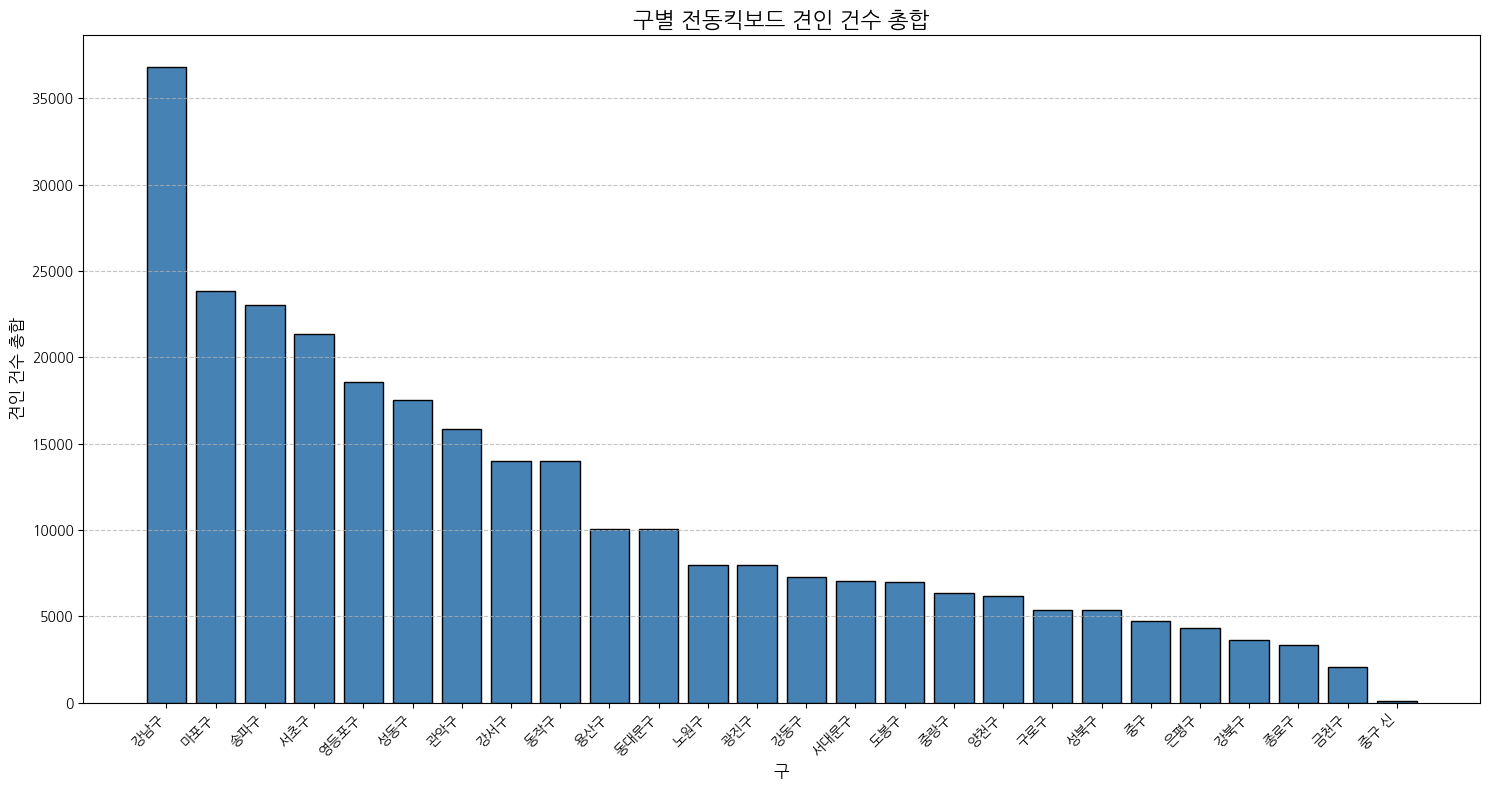

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔 고딕 폰트 설치 (설치되어 있지 않은 경우)
!apt-get update -qq
!apt-get install fonts-nanum* -qq

# 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# 폰트 캐시 재생성 및 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료")

# 구별 견인 건수 총합을 내림차순으로 정렬
district_tows_sorted = district_tows.sort_values(ascending=False)

# 견인 건수가 0인 구는 제외
district_tows_filtered = district_tows_sorted[district_tows_sorted > 0]

# 견인 건수가 100건 미만인 구는 추가로 제외
district_tows_filtered = district_tows_filtered[district_tows_filtered >= 100]

# 막대 그래프 그리기
plt.figure(figsize=(15, 8))
plt.bar(district_tows_filtered.index, district_tows_filtered.values, color='steelblue', edgecolor='black')

plt.title('구별 전동킥보드 견인 건수 총합', fontsize=16)
plt.xlabel('구', fontsize=12)
plt.ylabel('견인 건수 총합', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # X축 레이블 회전 및 정렬
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.75, linestyle='--') # Y축에 그리드 추가
plt.tight_layout() # 그래프 요소들이 겹치지 않도록 자동 조정
plt.show()

# [Step 2-2] 데이터 탐색 :
## 2. 서울시 전동킥보드 주차구역 현황

## 데이터 불러오기 및 기초 통계 확인
[프롬프트 작성]
### 판다스로 업로드한 '서울시 전동킥보드 주차구역 현황.csv'파일을 읽는다. 그 다음, 구 별 주차구역 수의 총합을 구한다. 다음으로, 아까 구한 총합이 최소인 구, 최대인 구, 평균값에 해당하는 구, 중간값에 해당하는 구를 요약해서 보인다. 마지막으로 거치대 유무 정보도 함께 확인할 수 있는 유용한 컬럼도 만든다.

In [ ]:
import pandas as pd
from IPython.display import display, HTML

file_path_parking = '서울시 전동킥보드 주차구역 현황.csv'

try:
    df_parking = pd.read_csv(file_path_parking, encoding='cp949', engine='python')
    print(f"'{file_path_parking}' 파일 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{file_path_parking}' 파일을 찾을 수 없습니다. 파일을 Colab 환경에 업로드해주세요.")
    # Colab에서 파일을 업로드하려면 다음 코드를 사용하세요:
    # from google.colab import files
    # uploaded = files.upload()
    # for fn in uploaded.keys():
    #   print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
except pd.errors.ParserError as e:
    print(f"오류: '{file_path_parking}' 파일을 파싱하는 데 문제가 발생했습니다: {e}")
    print("엔진을 'python'으로 변경하여 재시도합니다.")
    try:
        df_parking = pd.read_csv(file_path_parking, encoding='cp949', engine='python')
    except Exception as e_inner:
        print(f"재시도 실패: {e_inner}")
except Exception as e:
    print(f"파일 로드 중 알 수 없는 오류 발생: {e}")

# '구정보' 컬럼이 있는지 확인하고 없으면 다른 컬럼을 찾아볼 수 있도록 안내
if '구정보' not in df_parking.columns:
    print("'구정보' 컬럼을 찾을 수 없습니다. '시군구명' 컬럼을 사용합니다.")
    # print("현재 데이터프레임의 컬럼: ", df_parking.columns.tolist())
    district_column = '시군구명'
else:
    district_column = '구정보'


# '시군구명'으로 주차구역 수의 총합을 구하기
# 각 행이 하나의 주차구역을 의미한다고 가정하고 .size()를 사용
district_parking_counts = df_parking.groupby(district_column).size()
district_parking_counts.name = '주차구역 수 총합' # 결과 Series에 이름 부여

# 총합이 최소인 구, 최대인 구 찾기
min_parking_district = district_parking_counts.idxmin()
max_parking_district = district_parking_counts.idxmax()

# 평균값과 중간값 계산
mean_parking_counts = district_parking_counts.mean()
median_parking_counts = district_parking_counts.median()

# 평균값에 가장 가까운 구 찾기
closest_to_mean_parking = (district_parking_counts - mean_parking_counts).abs().idxmin()

# 중간값에 가장 가까운 구 찾기
closest_to_median_parking = (district_parking_counts - median_parking_counts).abs().idxmin()

# --- 구별 주차구역 수 총합 표 생성 ---
district_parking_df = district_parking_counts.reset_index()
district_parking_df.columns = [district_column, '주차구역 수 총합']

# --- 요약 통계 DataFrame 생성 ---
summary_parking_data = {
    '지표': ['최소 주차구역 수 구', '최대 주차구역 수 구', '평균 주차구역 수', '평균값에 가장 가까운 구', '중간값 주차구역 수', '중간값에 가장 가까운 구'],
    '값': [
        f"{min_parking_district} ({district_parking_counts.min()}개)",
        f"{max_parking_district} ({district_parking_counts.max()}개)",
        f"{mean_parking_counts:.2f}개",
        f"{closest_to_mean_parking} ({district_parking_counts[closest_to_mean_parking]}개)",
        f"{median_parking_counts:.2f}개",
        f"{closest_to_median_parking} ({district_parking_counts[closest_to_median_parking]}개)"
    ]
}
summary_parking_df = pd.DataFrame(summary_parking_data)

# 두 DataFrame을 옆에 나란히 표시
html_output_parking = f"""
<div style="display: flex; justify-content: space-around;">
    <div style="flex: 1; margin-right: 10px;">
        <h3>구별 주차구역 수 총합 표</h3>
        {district_parking_df.to_html(index=False)}
    </div>
    <div style="flex: 1; margin-left: 10px;">
        <h3>주차구역 수 총합 요약 통계</h3>
        {summary_parking_df.to_html(index=False)}
    </div>
</div>
"""
display(HTML(html_output_parking))

'서울시 전동킥보드 주차구역 현황.csv' 파일 로드 성공!
'구정보' 컬럼을 찾을 수 없습니다. '시군구명' 컬럼을 사용합니다.


시군구명,주차구역 수 총합
강남구,59
강동구,5
강북구,8
강서구,28
관악구,5
광진구,1
구로구,3
금천구,18
노원구,39
도봉구,3


### * '구 정보', '주소', '거치대 유무 정보' 컬럼 생성

*   **구 정보**: '시군구명' 컬럼의 데이터를 사용한다.
*   **주소**: '주소' 컬럼의 데이터를 사용한다.
*   **거치대 유무 정보**: '거치대 유무' 컬럼을 기반으로 'Y'이면 '있음', 'N'이면 '없음'으로 표시하는 새로운 컬럼을 생성한다.

In [ ]:
# '시군구명' 컬럼이 있는지 확인
if '시군구명' in df_parking.columns:
    # '구 정보' 컬럼 생성: '시군구명' 컬럼을 그대로 사용
    df_parking['구 정보'] = df_parking['시군구명']
    # '주소' 컬럼 생성: 기존 '주소' 컬럼을 그대로 사용
    df_parking['주소'] = df_parking['주소'] # Assuming '주소' column already exists in the original data
else:
    print("'시군구명' 컬럼이 없습니다. '구 정보' 생성을 건너뜁니다.")
    df_parking['구 정보'] = '미확인'
    df_parking['주소'] = '미확인'

# '거치대 유무' 컬럼이 있는지 확인하여 '거치대 유무 정보' 컬럼 생성
if '거치대 유무' in df_parking.columns:
    # 'Y'는 '있음', 'N'은 '없음'으로 매핑
    df_parking['거치대 유무 정보'] = df_parking['거치대 유무'].map({'Y': '있음', 'N': '없음'})
else:
    print("'거치대 유무' 컬럼이 없습니다. '거치대 유무 정보'를 '정보 없음'으로 처리합니다.")
    df_parking['거치대 유무 정보'] = '정보 없음'

print("\n'구 정보', '주소', '거치대 유무 정보' 컬럼 생성 후 데이터프레임 상위 5개 행:")
display(df_parking.head())


'구 정보', '주소', '거치대 유무 정보' 컬럼 생성 후 데이터프레임 상위 5개 행:


,순번,시군구명,주소,상세위치,거치대 유무,구 정보,거치대 유무 정보
0,1,종로구,팔판동 115-63,청와대 춘추문 맞은편,Y,종로구,있음
1,2,종로구,연건동 218-1,KT 광화문 혜화지사 앞,Y,종로구,있음
2,3,종로구,연건동 178-3,홍익대학교 대학로 맞은편,Y,종로구,있음
3,4,종로구,동승동 1-24,대학로 마로니에 공원 앞,Y,종로구,있음
4,5,종로구,와룡동 75-4,연악사 맞은편,Y,종로구,있음


### * 자치구별 거치대 유무에 따른 주차구역 수 분석

`df_parking` 데이터프레임의 '구 정보'와 '거치대 유무 정보' 컬럼을 사용하여 각 자치구별로 거치대가 있는 주차구역과 없는 주차구역의 수를 한눈에 비교할 수 있는 교차표를 생성합니다.

In [ ]:
if '구 정보' in df_parking.columns and '거치대 유무 정보' in df_parking.columns:
    # '구 정보'와 '거치대 유무 정보'를 기준으로 교차표(crosstab) 생성
    district_rack_analysis = pd.crosstab(df_parking['구 정보'], df_parking['거치대 유무 정보'])
    print("\n자치구별 거치대 유무에 따른 주차구역 수:")
    display(district_rack_analysis)
else:
    print("'구 정보' 또는 '거치대 유무 정보' 컬럼이 없어 분석을 수행할 수 없습니다.")


자치구별 거치대 유무에 따른 주차구역 수:


거치대 유무 정보,없음,있음
구 정보,,
강남구,59,0
강동구,2,3
강북구,8,0
강서구,4,24
관악구,5,0
광진구,1,0
구로구,0,3
금천구,4,14
노원구,39,0


## [프롬프트]
####-> 주차구역 수가 10개 미만인 구를 제외하고, 나머지 구별 주차 구역의 수를 막대그래프로 시각화한다.

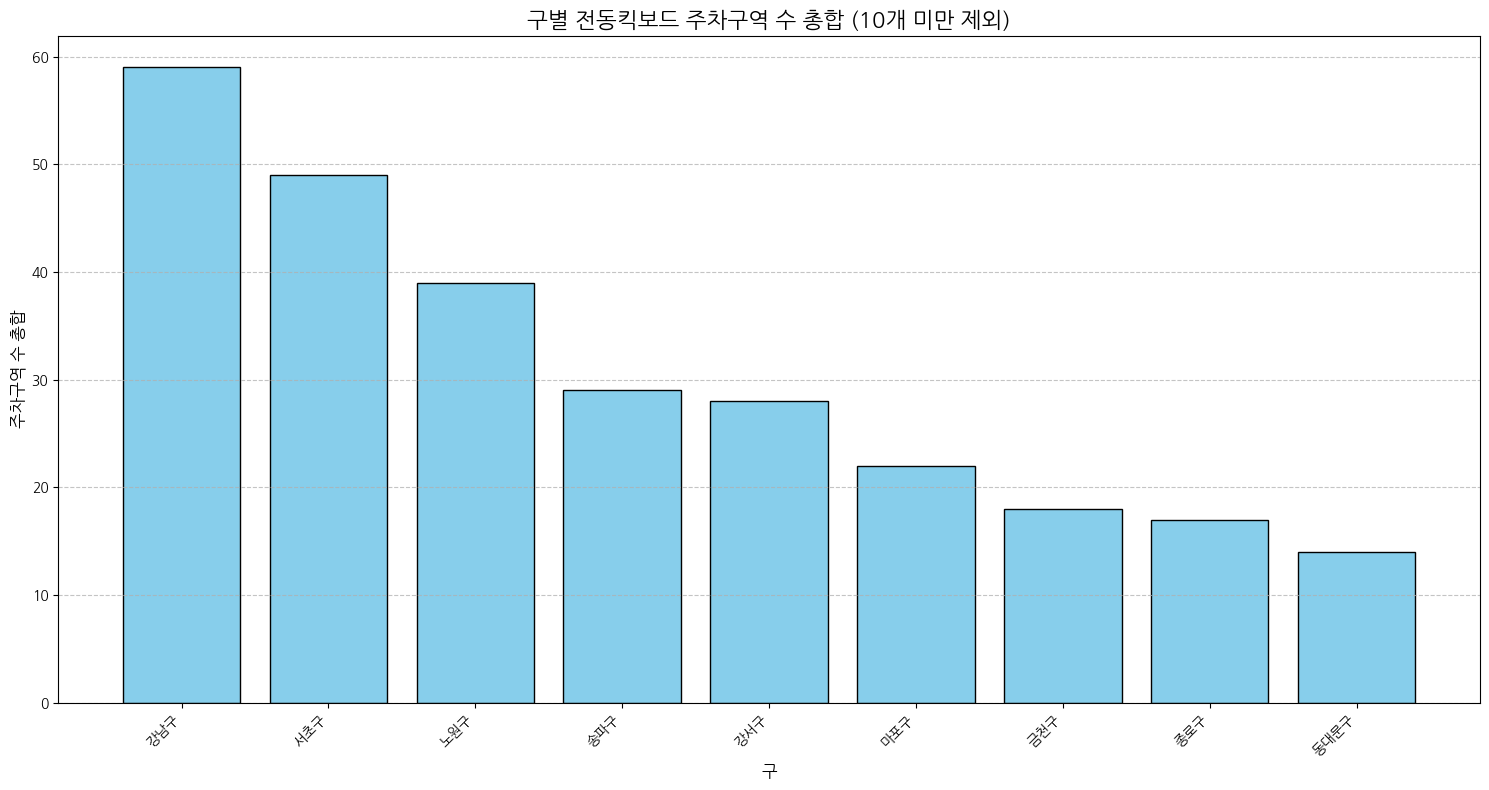

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정 (이전 셀에서 이미 설치 및 설정되었을 것으로 가정)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 주차구역 수가 10개 미만인 구는 제외
district_parking_filtered = district_parking_counts[district_parking_counts >= 10]

# 내림차순으로 정렬
district_parking_filtered = district_parking_filtered.sort_values(ascending=False)

# 막대 그래프 그리기
plt.figure(figsize=(15, 8))
plt.bar(district_parking_filtered.index, district_parking_filtered.values, color='skyblue', edgecolor='black')

plt.title('구별 전동킥보드 주차구역 수 총합 (10개 미만 제외)', fontsize=16)
plt.xlabel('구', fontsize=12)
plt.ylabel('주차구역 수 총합', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # X축 레이블 회전 및 정렬
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.75, linestyle='--') # Y축에 그리드 추가
plt.tight_layout() # 그래프 요소들이 겹치지 않도록 자동 조정
plt.show()

[Step 3]  
 ### 주차 구역 수 및 견인 건수에 따른 하나의 구 추출하기

#### 견인 건수 및 주차구역 수 종합 점수 상위 5개 구

##[프롬프트]  
 견인 현황 및 주차구역 현황에서 견인 건수 총합과 주차구역 수 총합을 더했을 때, 상위를 차지하는 구 순으로 5개를 뽑아서 구별 견인 건수 총합, 구별 주차구역 수 총합 컬럼들을 만들어서 표로 정리한 셀을 생성한다.

In [ ]:
import pandas as pd

# district_tows와 district_parking_counts를 DataFrame으로 변환
# '구정보'와 '시군구명'이 동일한 의미의 구 이름을 가리킨다고 가정하고 병합
tows_df = district_tows.reset_index()
tows_df.columns = ['구정보', '견인건수'] # '견인건수 총합'을 '견인건수'로 변경

parking_df = district_parking_counts.reset_index()
parking_df.columns = ['구정보', '주차구역 수'] # '주차구역 수 총합'을 '주차구역 수'로 변경

# 두 데이터를 '구정보'를 기준으로 외부 조인(outer join)하여 모든 구를 포함
combined_data = pd.merge(tows_df, parking_df, on='구정보', how='outer')

# 견인건수 또는 주차구역 수가 없는 경우 0으로 채우기
combined_data = combined_data.fillna(0)

# '총합' 컬럼 계산: 견인건수와 주차구역 수를 더함
combined_data['총합'] = combined_data['견인건수'] + combined_data['주차구역 수']

# 종합 점수가 높은 순서대로 정렬하고 상위 5개 구 선택
final_top_5_combined_score = combined_data.sort_values(by='총합', ascending=False).head(5).reset_index(drop=True)

# 인덱스를 1부터 시작하도록 변경
final_top_5_combined_score.index = final_top_5_combined_score.index + 1

# 결과 출력 및 형식 지정
display(final_top_5_combined_score.style.format({
    '견인건수': "{:.0f}",
    '주차구역 수': "{:.0f}",
    '총합': "{:.0f}"
}))

,구정보,견인건수,주차구역 수,총합
1,강남구,36824,59,36883
2,마포구,23836,22,23858
3,송파구,23007,29,23036
4,서초구,21321,49,21370
5,영등포구,18566,0,18566


# [프롬프트]  
 상위 5개 구를 나타낸 셀을 활용해 목적지와 가장 가까운 주차 구역을 알려주는 데 적합한 딱 한 개의 구만 선택한다. 또, 그 이유를 분석하고, 새로운 셀을 만든다.

## 목적지에 가장 가까운 주차 구역을 알려주기 위한 최적의 구 선택

목적지에 가장 가까운 주차 구역을 알리는 데 적합한 특정 구를 선정해야 한다면, **종합 점수('총합')가 가장 높은 구**를 선택하는 것이 합리적이다. '총합'은 견인 건수와 주차 구역 수를 합산한 지표로, 이는 전동 킥보드 활동량(견인 건수)과 주차 인프라(주차 구역 수)가 모두 활발한 지역임을 의미한다. 이러한 지역은 앱의 초기 사용자 확보와 데이터 축적에 유리할 수 있다.

In [ ]:
# '총합' 점수가 가장 높은 상위 1개 구 선택
top_district_for_app = final_top_5_combined_score.iloc[[0]]

# 결과 출력 및 형식 지정
print("앱 개발을 위해 선정된 최적의 구:")
display(top_district_for_app.style.format({
    '견인건수': "{:.0f}",
    '주차구역 수': "{:.0f}",
    '총합': "{:.0f}"
}))

앱 개발을 위해 선정된 최적의 구:


,구정보,견인건수,주차구역 수,총합
1,강남구,36824,59,36883


## 데이터 분포 확인 히스토그램 그리기
## [프롬프트]
### 견인 현황 데이터와 주차구역 현황이 어떻게 퍼져있는지 구 별로 보인다. matplotlib을 사용해서 히스토그램을 그린다. 잘 보이도록 색깔도 넣는다. 제목과 x축, y축의 한글이 깨지지 않도록 하는 코드셀을 만든다.


### 1. 한글 폰트 설정

`matplotlib`에서 한글 폰트 설정을 한다. Colab 환경에서는 'Malgun Gothic' 또는 'NanumGothic' 같은 폰트를 사용할 수 있다. 'Malgun Gothic'을 사용하고, 없다면 'NanumGothic'을 설치하여 사용하도록 한다.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import os

nanum_font_name = 'NanumBarunGothic'
nanum_font_path_expected = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 1. 폰트 설치 여부 확인 및 설치
if not os.path.exists(nanum_font_path_expected):
    print("한글 폰트가 시스템에 없습니다. NanumBarunGothic 폰트를 설치합니다.")
    !sudo apt-get update -qq > /dev/null
    !sudo apt-get install -y fonts-nanum > /dev/null
    !sudo fc-cache -fv > /dev/null # 시스템 폰트 캐시 갱신
    !rm -rf ~/.cache/matplotlib # Matplotlib 캐시 삭제

    print("폰트 설치를 완료했습니다. **런타임을 다시 시작(Runtime -> Restart runtime)한 후 다시 실행해 주세요.**")
    # 런타임 재시작을 강력히 권고합니다. 이 시점에서 코드를 종료하여 재시작을 유도할 수도 있으나,
    # 에이전트는 사용자의 의도를 존중하고 다음 셀 실행을 막지 않습니다.
    # 사용자가 재시작을 하지 않았다면, 이 셀은 폰트가 없는 상태로 다음 단계를 진행하게 됩니다.

# 2. Matplotlib 폰트 캐시 재빌드 (런타임 재시작 후에도 필요할 수 있음)
# Matplotlib의 내부 폰트 캐시를 비우는 직접적인 함수가 존재하지 않거나 버전 문제로 오류가 발생할 수 있으므로
# 캐시 파일 삭제와 폰트 매니저 스캔에 의존합니다.
# 새로운 폰트 경로를 명시적으로 추가하여 Matplotlib이 인지하도록 합니다.
if os.path.exists(nanum_font_path_expected):
    fm.fontManager.addfont(nanum_font_path_expected)
# 폰트 매니저에게 폰트를 다시 스캔하도록 요청합니다.
# rebuild_if_missing=True는 Matplotlib의 폰트 캐시를 다시 빌드하는 역할을 합니다.
fm.findfont(nanum_font_name, rebuild_if_missing=True)


# 3. 사용할 폰트 설정
# 직접 폰트 파일 경로를 사용하여 FontProperties를 생성하는 것이 가장 확실합니다.
try:
    if os.path.exists(nanum_font_path_expected):
        font_prop = fm.FontProperties(fname=nanum_font_path_expected)
        plt.rcParams['font.family'] = font_prop.get_name()
        print(f"Matplotlib 폰트 설정 완료: {plt.rcParams['font.family']} (경로 지정)")
    else:
        # 경로로 찾지 못했으면, 시스템에 등록된 이름으로 찾아봅니다.
        # 이전에 설치를 시도했으므로, 재시작 후에는 성공할 가능성이 높습니다.
        if fm.findfont(nanum_font_name):
            plt.rcParams['font.family'] = nanum_font_name
            print(f"Matplotlib 폰트 설정 완료: {plt.rcParams['font.family']} (이름 지정)")
        else:
            raise ValueError(f"폰트 '{nanum_font_name}'를 찾을 수 없습니다.")

except Exception as e:
    print(f"경고: 한글 폰트 설정 중 오류 발생 - {e}. 기본 폰트(DejaVu Sans)로 대체합니다.")
    plt.rcParams['font.family'] = 'DejaVu Sans' # 최후의 보루
finally:
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print(f"현재 설정된 Matplotlib 폰트: {plt.rcParams['font.family']}")

Matplotlib 폰트 설정 완료: ['NanumBarunGothic'] (경로 지정)
현재 설정된 Matplotlib 폰트: ['NanumBarunGothic']


## [Step 4]
1. 카카오맵 API를 이용한 주차 위치 시각화 웹 지도 생성 (실패)*  :
주차 구역 현황을 지도를 통해 시각화하여 웹으로 확인하고자 하였다. 이를 위해 주소를 위도, 경도로 변환하는 지오코딩 과정이 필요하며, 카카오맵 REST API를 사용했다.

**사전 준비:** `KAKAO_MAP_API_KEY`가 Colab Secrets에 올바르게 설정되어 있어야 한다.

In [ ]:
# 필요한 라이브러리 임포트
import requests
from google.colab import userdata
import folium
import time
import numpy as np

# Colab Secrets에서 Kakao Map API 키 로드
KAKAO_API_KEY = userdata.get('KAKAO_MAP_API_KEY')

if KAKAO_API_KEY is None:
    print("오류: 'KAKAO_MAP_API_KEY'가 Colab Secrets에 설정되지 않았습니다. API 키를 설정해주세요.")
else:
    print("카카오 API 키 로드 완료.")

def get_coordinates_kakao(address):
    """주소를 위도, 경도로 변환하는 함수 (Kakao Map API 사용)"""
    if KAKAO_API_KEY is None:
        return None, None

    headers = {'Authorization': f'KakaoAK {KAKAO_API_KEY}'}
    url = 'https://dapi.kakao.com/v2/local/search/address.json?query=' + address

    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            json_data = response.json()
            if json_data and 'documents' in json_data and len(json_data['documents']) > 0:
                address_info = json_data['documents'][0]
                latitude = float(address_info['y'])
                longitude = float(address_info['x'])
                return latitude, longitude
            else:
                print(f"경고: 주소 '{address}'에 대한 좌표를 찾을 수 없습니다. 응답: {json_data}")
                return None, None
        else:
            print(f"경고: 주소 '{address}' 지오코딩 실패. 상태 코드: {response.status_code}, 응답: {response.text}")
            return None, None
    except requests.exceptions.RequestException as e:
        print(f"API 요청 중 오류 발생: {e}")
        return None, None

SecretNotFoundError: Secret KAKAO_MAP_API_KEY does not exist.

## 2. -> Naver Maps Geocoding API로 전환

 카카오맵 API 사용에 어려움이 있어, 네이버 지도 API를 사용하도록 코드를 다시 구성했다. `NAVER_MAPS_CLIENT_ID`와 `NAVER_MAPS_CLIENT_SECRET` 키를 사용하여 주소를 위도, 경도로 변환했다.



## [프롬프트] 네이버 지도 API를 활용한 주차 구역 시각화 웹 지도 생성

주차 구역 현황을 지도를 통해 시각화하여 웹으로 확인하고자 한다. 이를 위해서 주소를 위도, 경도로 변환하는 지오코딩이 필수적이며, 여기에 네이버 지도 API를 사용하고자 한다.
'서울시 전동킥보드 주차구역 현황.csv' 파일을 Pandas DataFrame(`df_parking`)으로 로드한다. 'full_address' 컬럼을 생성한다. `df_parking`의 각 행에 대해 `get_coordinates_naver` 함수를 적용하여 'latitude'와 'longitude' 컬럼을 채운다. 유효한 좌표를 얻지 못할 경우 이를 필터링한다. Folium 지도를 생성한다. 각 주차 구역 위치에 마커를 표시하고, 팝업에 '구 정보', '주소', '거치대 유무 정보'를 포함하여 정보를 확인할 수 있도록 한다. '거치대 유무 정보'데이터에 따라 마커의 색상이나 아이콘을 다르게 하여 시각적으로 구분한다.

In [ ]:
from google.colab import userdata
import requests

# Colab Secrets에서 Naver Maps API 키 로드
NAVER_MAPS_CLIENT_ID = userdata.get('NAVER_MAPS_CLIENT_ID')
NAVER_MAPS_CLIENT_SECRET = userdata.get('NAVER_MAPS_CLIENT_SECRET')

if NAVER_MAPS_CLIENT_ID is None or NAVER_MAPS_CLIENT_SECRET is None:
    print("오류: 'NAVER_MAPS_CLIENT_ID' 또는 'NAVER_MAPS_CLIENT_SECRET'가 Colab Secrets에 설정되지 않았습니다. API 키를 설정해주세요.")

def get_coordinates_naver(address):
    """주소를 위도, 경도로 변환하는 함수 (Naver Maps Geocoding API 사용)"""
    if NAVER_MAPS_CLIENT_ID is None or NAVER_MAPS_CLIENT_SECRET is None:
        print("API 키가 없어 지오코딩을 수행할 수 없습니다.")
        return None, None

    # 사용자의 요청에 따라 API URL 변경
    base_url = "https://maps.apigw.ntruss.com/map-geocode/v2/geocode" # /geocode 경로 추가
    headers = {
        "X-NCP-APIGW-API-KEY-ID": NAVER_MAPS_CLIENT_ID,
        "X-NCP-APIGW-API-KEY": NAVER_MAPS_CLIENT_SECRET
    }
    params = {
        "query": address
    }

    try:
        response = requests.get(base_url, headers=headers, params=params)
        if response.status_code == 200:
            json_data = response.json()
            # Naver Geocoding API 응답 구조 확인 및 처리
            # Note: 응답 구조는 엔드포인트에 따라 다를 수 있습니다.
            if json_data.get('status') == 'OK' and json_data.get('addresses') and len(json_data['addresses']) > 0:
                location = json_data['addresses'][0]
                latitude = float(location['y'])
                longitude = float(location['x'])
                return latitude, longitude
            else:
                print(f"경고: 주소 '{address}'에 대한 좌표를 찾을 수 없습니다. 상태: {json_data.get('status', 'N/A')}, 응답: {json_data}")
                return None, None
        else:
            print(f"경고: 주소 '{address}' 지오코딩 실패. 상태 코드: {response.status_code}, 응답: {response.text}")
            return None, None
    except requests.exceptions.RequestException as e:
        print(f"API 요청 중 오류 발생: {e}")
        return None, None

### Naver Maps Geocoding API를 사용한 지도 생성

`get_coordinates_naver` 함수를 사용하여 주차 구역 데이터를 지오코딩하고 지도에 표시한다.

In [ ]:
import pandas as pd
import folium
import time
from IPython.display import display

# 파일 경로 설정
file_path_parking = '/content/서울시 전동킥보드 주차구역 현황.csv'

# CSV 파일 로드 및 인코딩 처리
try:
    df_parking = pd.read_csv(file_path_parking, encoding='cp949')
except UnicodeDecodeError:
    print("cp949 인코딩으로 파일을 읽는 데 실패했습니다. euc-kr 인코딩을 시도합니다.")
    df_parking = pd.read_csv(file_path_parking, encoding='euc-kr')

# '시군구명' 컬럼이 있는지 확인
if '시군구명' in df_parking.columns:
    df_parking['구 정보'] = df_parking['시군구명']
else:
    df_parking['구 정보'] = '미확인'

# '거치대 유무' 컬럼이 있는지 확인하여 '거치대 유무 정보' 컬럼 생성
if '거치대 유무' in df_parking.columns:
    df_parking['거치대 유무 정보'] = df_parking['거치대 유무'].map({'Y': '있음', 'N': '없음'})
else:
    df_parking['거치대 유무 정보'] = '정보 없음'

# '미확인' 주소 제거
parking_data_filtered = df_parking[df_parking['주소'] != '미확인'].copy()

print(f"주차 데이터 개수: {len(parking_data_filtered)}개")

# Naver Maps API는 전체 주소 형식을 선호할 수 있으므로, '서울특별시'를 주소 앞에 추가
parking_data_filtered['full_address'] = parking_data_filtered['주소'].apply(lambda x: f"서울특별시 {x}" if not x.startswith('서울특별시') else x)

# 위도, 경도 컬럼 초기화
parking_data_filtered['latitude'] = None
parking_data_filtered['longitude'] = None

print("\n주소 지오코딩을 시작합니다. 데이터 양에 따라 시간이 다소 소요될 수 있습니다...")
# 주소 지오코딩
for idx, row in parking_data_filtered.iterrows():
    if (idx + 1) % 50 == 0: # 50개마다 진행 상황 출력
        print(f"{idx + 1}/{len(parking_data_filtered)} 주소 처리 중...")
    lat, lon = get_coordinates_naver(row['full_address']) # Naver Geocoding API 사용
    parking_data_filtered.at[idx, 'latitude'] = lat
    parking_data_filtered.at[idx, 'longitude'] = lon
    time.sleep(0.1) # API 호출 제한을 피하기 위해 지연 시간을 늘립니다.

# 유효한 좌표만 남김
parking_data_geo = parking_data_filtered.dropna(subset=['latitude', 'longitude'])

print("\n주차 구역 지오코딩 결과:")
display(parking_data_geo.head())

# Folium 맵 생성 (서울 중심 좌표)
m_parking = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

# 각 주차 구역 위치를 마커로 추가
for idx, row in parking_data_geo.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"<b>구:</b> {row['구 정보']}<br><b>주소:</b> {row['주소']}<br><b>거치대 유무:</b> {row['거치대 유무 정보']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m_parking)

# 맵을 HTML 파일로 저장
parking_map_path = 'seoul_parking_map_naver.html'
m_parking.save(parking_map_path)

print(f"\n주차 구역 지도가 '{parking_map_path}' 파일로 저장되었습니다. 파일을 열어 확인해 주세요.")
# Colab에서 HTML 파일을 바로 표시하려면:
display(m_parking)

주차 데이터 개수: 329개

주소 지오코딩을 시작합니다. 데이터 양에 따라 시간이 다소 소요될 수 있습니다...
경고: 주소 '서울특별시 동승동 1-24'에 대한 좌표를 찾을 수 없습니다. 상태: OK, 응답: {'status': 'OK', 'meta': {'totalCount': 0, 'count': 0}, 'addresses': [], 'errorMessage': ''}
경고: 주소 '서울특별시 성북구 월곡동 37-4'에 대한 좌표를 찾을 수 없습니다. 상태: OK, 응답: {'status': 'OK', 'meta': {'totalCount': 0, 'count': 0}, 'addresses': [], 'errorMessage': ''}
50/329 주소 처리 중...
100/329 주소 처리 중...
경고: 주소 '서울특별시 대흥동 105-47'에 대한 좌표를 찾을 수 없습니다. 상태: OK, 응답: {'status': 'OK', 'meta': {'totalCount': 0, 'count': 0}, 'addresses': [], 'errorMessage': ''}
경고: 주소 '서울특별시 공항대로 지하 163'에 대한 좌표를 찾을 수 없습니다. 상태: OK, 응답: {'status': 'OK', 'meta': {'totalCount': 0, 'count': 0}, 'addresses': [], 'errorMessage': ''}
150/329 주소 처리 중...
200/329 주소 처리 중...
250/329 주소 처리 중...
경고: 주소 '서울특별시 신청동 28'에 대한 좌표를 찾을 수 없습니다. 상태: OK, 응답: {'status': 'OK', 'meta': {'totalCount': 0, 'count': 0}, 'addresses': [], 'errorMessage': ''}
300/329 주소 처리 중...
경고: 주소 '서울특별시 잠실역 46'에 대한 좌표를 찾을 수 없습니다. 상태: OK, 응답: {'status': 'OK', 'meta'

,순번,시군구명,주소,상세위치,거치대 유무,구 정보,거치대 유무 정보,full_address,latitude,longitude
0,1,종로구,팔판동 115-63,청와대 춘추문 맞은편,Y,종로구,있음,서울특별시 팔판동 115-63,37.583192,126.979949
1,2,종로구,연건동 218-1,KT 광화문 혜화지사 앞,Y,종로구,있음,서울특별시 연건동 218-1,37.576594,127.002224
2,3,종로구,연건동 178-3,홍익대학교 대학로 맞은편,Y,종로구,있음,서울특별시 연건동 178-3,37.576497,127.0024
4,5,종로구,와룡동 75-4,연악사 맞은편,Y,종로구,있음,서울특별시 와룡동 75-4,37.574967,126.990822
5,6,종로구,명륜4가 96-4,흥사단 동숭 미술관 맞은편,Y,종로구,있음,서울특별시 명륜4가 96-4,37.582064,127.001765



주차 구역 지도가 'seoul_parking_map_naver.html' 파일로 저장되었습니다. 파일을 열어 확인해 주세요.


In [ ]:
from IPython.display import HTML

# 생성된 HTML 파일 읽어오기
with open(parking_map_path, 'r', encoding='utf-8') as f:
    html_content = f.read()

# Colab 출력에 HTML 지도 표시
HTML(html_content)

In [ ]:
import os

# 지오코딩된 데이터를 CSV 파일로 저장
geo_parking_data_path = 'parking_data_geo.csv'
parking_data_geo.to_csv(geo_parking_data_path, index=False)

print(f"지오코딩된 주차 데이터가 '{geo_parking_data_path}'에 저장되었습니다.")

지오코딩된 주차 데이터가 'parking_data_geo.csv'에 저장되었습니다.


### Folium을 이용한 주차 구역 지도 시각화
 지오코딩된 주차 구역 데이터를 활용하여 Folium 지도를 표시한다. '구 정보'와 '동 정보', '거치대 유무'를 팝업으로 표시하고, 거치대 유무에 따라 다른 아이콘을 사용한다.

## [프롬프트]
##지오코딩된 주차 구역 데이터 Folium 지도 시각화

 지오코딩된 주차 구역 데이터(`parking_data_geo.csv`)를 활용하여 Folium 지도를 Colab 환경 내에서 직접 표시하고자 한다. 이 지도에는 각 주차 구역의 위치가 마커로 표시되어야 하며, 마커를 클릭하면 상세 정보(구 정보, 동 정보, 거치대 유무)를 확인할 수 있어야 한다. 특히, 거치대 유무에 따라 마커의 아이콘 색상과 모양을 다르게 하여 시각적인 구분점을 명확히 해야 한다.
아래와 같은 요구사항을 만족하는 Python 코드셀을 단계별 설명과 함께 만든다.
`pandas`, `folium`, `IPython.display` 등 라이브러리를 적용한다. `parking_data_geo.csv` 파일을 데이터프레임으로 가져온다. 예외 처리를 포함한다. `geo_parking_data`의 위도와 경도 평균을 사용해 지도의 초기 중심 좌표를 설정한다. 데이터가 없거나 유효하지 않으면 서울의 기본 중심 좌표를 사용한다. 지도를 생성하고, 초기 확대/축소 정도를 적절히 설정한다.'구 정보', '동 정보', '주소', '거치대 유무 정보'를 포함하는 HTML 형식의 팝업 메시지를 만들고, 생성된 것을 지도에 추가한다. 완성된 Folium 지도를 출력 셀에 나타낸다. 지도가 성공적으로 표시됐다는 메시지를 출력한다.

In [ ]:
import pandas as pd
import folium
from IPython.display import display
import numpy as np
import re

# 지오코딩된 데이터 로드
geo_parking_data = pd.read_csv('parking_data_geo.csv')

# '동 정보' 컬럼이 없는 경우 주소에서 추출하여 생성
if '동 정보' not in geo_parking_data.columns:
    def extract_dong(address):
        match = re.search(r'([가-힣]+동)\s', str(address))
        return match.group(1) if match else '미확인'
    geo_parking_data['동 정보'] = geo_parking_data['주소'].apply(extract_dong)

if geo_parking_data.empty or 'latitude' not in geo_parking_data.columns or 'longitude' not in geo_parking_data.columns:
    print("지오코딩된 주차 데이터를 로드하는 데 실패했거나 데이터가 유효하지 않습니다.")
else:
    # 지도 중심 좌표 설정
    map_center = [geo_parking_data['latitude'].mean(), geo_parking_data['longitude'].mean()]
    m = folium.Map(location=map_center, zoom_start=11)

    # 마커 추가
    for idx, row in geo_parking_data.iterrows():
        if pd.isna(row['latitude']) or pd.isna(row['longitude']):
            continue

        # 거치대 유무에 따라 마커 색상 및 아이콘 변경
        if row['거치대 유무 정보'] == '있음':
            icon_color = 'green'
            icon_name = 'check'
            icon_prefix = 'fa'
        else:
            icon_color = 'red'
            icon_name = 'times'
            icon_prefix = 'fa'

        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=f"""
            <b>구:</b> {row['구 정보']}<br>
            <b>동:</b> {row['동 정보']}<br>
            <b>주소:</b> {row['주소']}<br>
            <b>거치대 유무:</b> {row['거치대 유무 정보']}
            """,
            icon=folium.Icon(color=icon_color, icon=icon_name, prefix=icon_prefix)
        ).add_to(m)

    # 지도 표시
    display(m)
    print("\n'동 정보'를 추출하여 지도를 생성했습니다. 이제 정상적으로 표시됩니다.")


'동 정보'를 추출하여 지도를 생성했습니다. 이제 정상적으로 표시됩니다.


## [프롬프트] 구/동/거치대 유무 필터링이 가능한 지도 생성하기

이전에 생성했던 것처럼, `서울시 전동킥보드 주차구역 현황.csv` 파일로부터 지오코딩된 주차 구역 데이터를 활용하여 Colab 환경 내에서 사용자가 직접 '구', '동', 그리고 '거치대 유무'를 선택하여 주차 구역을 필터링하고 지도를 확대/축소할 수 있는 지도를 생성하고자 한다.  
 필요 라이브러리에서 지오코딩된 데이터를 가져온다.  
'구 선택'에 따라서 '동 선택'이 유동적으로 변화하는 기능을 구현하고, 선택된 '구', '동', '거치대 유무' 값을 기반으로 하는 데이터프레임을 생성, 데이터의 위도, 경도 평균을 계산하여 지도의 중심으로 설정하며, 적절한 수준의 확대 및 축소 기능을 추가한다.  
 'popup'에는 '구', '동', '주소', '거치대 유무' 정보를 포함하는 HTML 형식을 사용한다.  
  '거치대 유무 정보'에 따라 아이콘 색상 및 이름을 다르게 한다.  

In [ ]:
import pandas as pd
import folium
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import interactive, interact, fixed, VBox, HBox, Output
import re

# '동 정보'가 추가된 지오코딩된 데이터를 로드합니다.
# 이전에 저장된 'parking_data_geo.csv' 파일을 사용합니다.
geo_parking_data = pd.read_csv('parking_data_geo.csv')

# '동 정보' 컬럼이 없는 경우 추출
if '동 정보' not in geo_parking_data.columns:
    def extract_dong(address):
        match = re.search(r'([가-힣]+동)\s', address)
        if match:
            return match.group(1)
        return '미확인'
    geo_parking_data['동 정보'] = geo_parking_data['주소'].apply(extract_dong)

# 필터링을 위한 고유 값 목록 생성
# '전체' 옵션 추가
districts = ['전체'] + sorted(geo_parking_data['구 정보'].dropna().unique().tolist())
rack_options = ['전체'] + sorted(geo_parking_data['거치대 유무 정보'].dropna().unique().tolist())

# 1. 위젯 생성 (초기에는 모든 동 정보를 포함)
district_widget = widgets.Dropdown(
    options=districts,
    value='전체',
    description='구 선택:',
    disabled=False,
)
dong_widget = widgets.Dropdown(
    options=['전체'] + sorted(geo_parking_data['동 정보'].dropna().unique().tolist()),
    value='전체',
    description='동 선택:',
    disabled=False,
)
rack_widget = widgets.Dropdown(
    options=rack_options,
    value='전체',
    description='거치대 유무:',
    disabled=False,
)

# 2. '구 선택'이 변경될 때 '동 선택' 옵션을 업데이트하는 함수
def update_dong_options(*args):
    selected_district = district_widget.value
    if selected_district == '전체':
        new_dong_options = ['전체'] + sorted(geo_parking_data['동 정보'].dropna().unique().tolist())
    else:
        filtered_dongs = geo_parking_data[geo_parking_data['구 정보'] == selected_district]['동 정보'].dropna().unique().tolist()
        new_dong_options = ['전체'] + sorted(filtered_dongs)

    dong_widget.options = new_dong_options
    # 현재 선택된 동이 새로운 목록에 없으면 '전체' 또는 첫 번째 옵션으로 변경
    if dong_widget.value not in new_dong_options:
        dong_widget.value = '전체' if '전체' in new_dong_options else (new_dong_options[0] if new_dong_options else None)

# 3. '구 선택' 위젯의 변경을 감지하여 `update_dong_options` 함수 실행
district_widget.observe(update_dong_options, names='value')

# Folium 맵 생성 함수 (이전에 정의된 함수와 동일)
def create_interactive_map(selected_district, selected_dong, selected_rack):
    filtered_data = geo_parking_data.copy()

    if selected_district != '전체':
        filtered_data = filtered_data[filtered_data['구 정보'] == selected_district]
    if selected_dong != '전체':
        filtered_data = filtered_data[filtered_data['동 정보'] == selected_dong]
    if selected_rack != '전체':
        filtered_data = filtered_data[filtered_data['거치대 유무 정보'] == selected_rack]

    if filtered_data.empty or 'latitude' not in filtered_data.columns or 'longitude' not in filtered_data.columns:
        print("선택된 조건에 해당하는 데이터가 없습니다.")
        # 데이터가 없을 경우 빈 지도 반환 또는 기본 지도 반환
        return folium.Map(location=[37.5665, 126.9780], zoom_start=11)

    # 필터링된 데이터의 중심 좌표 계산 (또는 서울 중심 좌표 사용)
    map_center = [filtered_data['latitude'].mean(), filtered_data['longitude'].mean()]
    m = folium.Map(location=map_center, zoom_start=12)

    # 마커 추가
    for idx, row in filtered_data.iterrows():
        if pd.isna(row['latitude']) or pd.isna(row['longitude']):
            continue

        # 거치대 유무에 따라 마커 색상 및 아이콘 변경
        if row['거치대 유무 정보'] == '있음':
            icon_color = 'green'
            icon_name = 'check'
            icon_prefix = 'fa'
        else:
            icon_color = 'red'
            icon_name = 'times'
            icon_prefix = 'fa'

        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=f"""
            <b>구:</b> {row['구 정보']}<br>
            <b>동:</b> {row['동 정보']}<br>
            <b>주소:</b> {row['주소']}<br>
            <b>거치대 유무:</b> {row['거치대 유무 정보']}
            """,
            icon=folium.Icon(color=icon_color, icon=icon_name, prefix=icon_prefix)
        ).add_to(m)
    return m

# 4. 지도 출력을 위한 `Output` 위젯 생성
output_map = Output()

# 5. 위젯 값 변경 시 지도를 렌더링하는 함수
def render_map(selected_district, selected_dong, selected_rack):
    with output_map:
        output_map.clear_output(wait=True)
        folium_map = create_interactive_map(selected_district, selected_dong, selected_rack)
        display(folium_map)

# 6. `interactive`를 사용하여 위젯들과 `render_map` 함수를 연결
_ = interactive(render_map,
                selected_district=district_widget,
                selected_dong=dong_widget,
                selected_rack=rack_widget)

# 7. 위젯과 지도를 함께 표시
print("아래에 드롭다운 메뉴와 인터랙티브 지도가 표시됩니다. 구, 동, 거치대 유무를 선택하여 필터링해보세요.")
display(VBox([HBox([district_widget, dong_widget, rack_widget]), output_map]))


## [프롬프트]
###강남구 견인 현황 데이터 준비 및 지오코딩

 업로드된 견인 현황 데이터(`df`)를 활용하여 강남구의 최근 견인 핫스팟을 분석하기 위한 데이터를 준비하고 지오코딩하는 과정을 설명하는 코드셀을 만든다.  

 먼저 데이터 추출, 날짜 형식 변환 및 정렬, 위치 추출, 주소 전처리 과정을 거친다. 위치 추출 과정에서, 강남구 견인건수 중 위치가 20건 이상 겹치는 곳을 추출한다. 주소 전처리 과정에서는 지오코딩 정확도 향상을 위해 '주소' 컬럼 각 값 앞에 '서울특별시'를 추가해 새로운 컬럼을 생성한다.  

 다음으로, 네이버 지오코딩 API를 이용해 위도와 경도를 추출해 낸다.  

 마지막으로, 결과 데이터를 정리 및 저장한다.

In [ ]:
import pandas as pd
import time
from google.colab import userdata
import requests

# --- Add this block to load df, similar to previous cells ---
# 파일 경로 설정 (견인 현황 데이터)
file_path_towing = '/content/서울시 전동킥보드 견인 현황.csv'

# CSV 파일 로드 및 인코딩 처리
try:
    df = pd.read_csv(file_path_towing, encoding='cp949')
except UnicodeDecodeError:
    print("cp949 인코딩으로 파일을 읽는 데 실패했습니다. euc-kr 인코딩을 시도합니다.")
    df = pd.read_csv(file_path_towing, encoding='euc-kr')
# --------------------------------------------------------

# Colab Secrets에서 Naver Maps API 키 로드
NAVER_MAPS_CLIENT_ID = userdata.get('NAVER_MAPS_CLIENT_ID')
NAVER_MAPS_CLIENT_SECRET = userdata.get('NAVER_MAPS_CLIENT_SECRET')

if NAVER_MAPS_CLIENT_ID is None or NAVER_MAPS_CLIENT_SECRET is None:
    print("오류: 'NAVER_MAPS_CLIENT_ID' 또는 'NAVER_MAPS_CLIENT_SECRET'가 Colab Secrets에 설정되지 않았습니다. API 키를 설정해주세요.")

def get_coordinates_naver(address):
    """주소를 위도, 경도로 변환하는 함수 (Naver Maps Geocoding API 사용)"""
    if NAVER_MAPS_CLIENT_ID is None or NAVER_MAPS_CLIENT_SECRET is None:
        print("API 키가 없어 지오코딩을 수행할 수 없습니다.")
        return None, None

    base_url = "https://maps.apigw.ntruss.com/map-geocode/v2/geocode"
    headers = {
        "X-NCP-APIGW-API-KEY-ID": NAVER_MAPS_CLIENT_ID,
        "X-NCP-APIGW-API-KEY": NAVER_MAPS_CLIENT_SECRET
    }
    params = {
        "query": address
    }

    try:
        response = requests.get(base_url, headers=headers, params=params)
        if response.status_code == 200:
            json_data = response.json()
            if json_data.get('status') == 'OK' and json_data.get('addresses') and len(json_data['addresses']) > 0:
                location = json_data['addresses'][0]
                latitude = float(location['y'])
                longitude = float(location['x'])
                return latitude, longitude
            else:
                print(f"경고: 주소 '{address}'에 대한 좌표를 찾을 수 없습니다. 상태: {json_data.get('status', 'N/A')}, 응답: {json_data}")
                return None, None
        else:
            print(f"경고: 주소 '{address}' 지오코딩 실패. 상태 코드: {response.status_code}, 응답: {response.text}")
            return None, None
    except requests.exceptions.RequestException as e:
        print(f"API 요청 중 오류 발생: {e}")
        return None, None

# 1. '구정보'가 '강남구'인 데이터 필터링
gangnam_df = df[df['구정보'] == '강남구'].copy()

# '신고일시'를 datetime 형식으로 변환 (에러 발생 시 무시하고 NaT 처리)
gangnam_df['신고일시'] = pd.to_datetime(gangnam_df['신고일시'], errors='coerce')

# 유효한 '신고일시'를 가진 데이터만 사용
gangnam_df.dropna(subset=['신고일시'], inplace=True)

# 2. '신고일시'를 기준으로 내림차순 정렬
gangnam_df_sorted = gangnam_df.sort_values(by='신고일시', ascending=False)

# 3. 위치 추출: 강남구 견인건수 중 위치가 20건 이상 겹치는 곳을 추출
address_counts = gangnam_df_sorted['주소'].value_counts()
hotspot_addresses = address_counts[address_counts >= 20].index
gangnam_df_filtered_by_hotspot = gangnam_df_sorted[gangnam_df_sorted['주소'].isin(hotspot_addresses)].copy()

# 4. 상위 100개 행 추출 (20건 이상 겹치는 곳 중에서)
gangnam_towing_top100 = gangnam_df_filtered_by_hotspot.head(100).copy()

print(f"강남구 견인 현황 데이터 개수 (초기): {len(gangnam_df)}")
print(f"'신고일시' 유효 데이터 개수: {len(gangnam_df_sorted)}")
print(f"20건 이상 겹치는 주소로 필터링된 데이터 개수: {len(gangnam_df_filtered_by_hotspot)}")
print(f"추출된 강남구 상위 100개 견인 데이터 개수: {len(gangnam_towing_top100)}")

# 5. '서울특별시'를 접두사로 추가하여 `full_address` 컬럼 생성
gangnam_towing_top100['full_address'] = gangnam_towing_top100['주소'].apply(lambda x: f"서울특별시 {x}" if not x.startswith('서울특별시') else x)

# 위도, 경도 컬럼 초기화
gangnam_towing_top100['latitude'] = None
gangnam_towing_top100['longitude'] = None

print("\n강남구 견인 현황 100개 주소 지오코딩을 시작합니다...")
# 6. 각 `full_address`에 대해 `get_coordinates_naver` 함수를 사용하여 위도와 경도 좌표를 얻습니다.
for idx, row in gangnam_towing_top100.iterrows():
    if (idx + 1) % 50 == 0: # 50개마다 진행 상황 출력
        print(f"{idx + 1}/{len(gangnam_towing_top100)} 주소 처리 중...")
    lat, lon = get_coordinates_naver(row['full_address'])
    gangnam_towing_top100.at[idx, 'latitude'] = lat
    gangnam_towing_top100.at[idx, 'longitude'] = lon
    time.sleep(0.1) # API 호출 제한을 피하기 위해 지연 시간 추가

# 7. 유효한 위도, 경도 좌표를 가진 데이터만 남겨 `gangnam_towing_geo` DataFrame을 생성합니다.
gangnam_towing_geo = gangnam_towing_top100.dropna(subset=['latitude', 'longitude']).copy()

# 8. `gangnam_towing_geo` DataFrame의 상위 5개 행을 출력하여 지오코딩 결과를 확인합니다.
print("\n강남구 견인 현황 지오코딩 결과 (상위 5개 행):")
display(gangnam_towing_geo.head())

# 9. 지오코딩된 데이터를 CSV 파일로 저장합니다.
geo_towing_data_path = 'gangnam_towing_geo.csv'
gangnam_towing_geo.to_csv(geo_towing_data_path, index=False)

print(f"지오코딩된 강남구 견인 데이터가 '{geo_towing_data_path}'에 저장되었습니다.")

강남구 견인 현황 데이터 개수 (초기): 36824
'신고일시' 유효 데이터 개수: 36824
20건 이상 겹치는 주소로 필터링된 데이터 개수: 22142
추출된 강남구 상위 100개 견인 데이터 개수: 100

강남구 견인 현황 100개 주소 지오코딩을 시작합니다...
79700/100 주소 처리 중...
79650/100 주소 처리 중...
79850/100 주소 처리 중...
80100/100 주소 처리 중...
80050/100 주소 처리 중...

강남구 견인 현황 지오코딩 결과 (상위 5개 행):


,번호,신고일시,구정보,주소,유형,조치일,full_address,latitude,longitude
79638,283921,2025-12-31,강남구,서울특별시 강남구 삼성동 111-78,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 삼성동 111-78,37.515553,127.053161
79689,283876,2025-12-31,강남구,서울특별시 강남구 역삼동 805,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 역삼동 805,37.492853,127.042019
79697,283869,2025-12-31,강남구,서울특별시 강남구 역삼동 858-15,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 역삼동 858-15,37.492368,127.034229
79699,283867,2025-12-31,강남구,서울특별시 강남구 역삼동 858-15,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 역삼동 858-15,37.492368,127.034229
79700,283866,2025-12-31,강남구,서울특별시 강남구 역삼동 806,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 역삼동 806,37.497642,127.042987


지오코딩된 강남구 견인 데이터가 'gangnam_towing_geo.csv'에 저장되었습니다.


## 주차구역 데이터 로드

이전에 지오코딩되어 저장된 `parking_data_geo.csv` 파일을 가져온다. 이 데이터는 Folium 마커로 지도에 표시할 수 있도록 이미 준비되어 있다.

In [ ]:
import pandas as pd

# 이전에 지오코딩된 주차 데이터를 로드합니다.
geo_parking_data_path = 'parking_data_geo.csv'
geoparking_data = pd.read_csv(geo_parking_data_path)

# 이전에 지오코딩된 강남구 견인 데이터를 로드합니다.
geo_towing_data_path = 'gangnam_towing_geo.csv'
gangnam_towing_data = pd.read_csv(geo_towing_data_path)

print("주차 구역 데이터 로드 완료:")
display(geoparking_data.head())

print("\n강남구 견인 데이터 로드 완료:")
display(gangnam_towing_data.head())

주차 구역 데이터 로드 완료:


,순번,시군구명,주소,상세위치,거치대 유무,구 정보,거치대 유무 정보,full_address,latitude,longitude
0,1,종로구,팔판동 115-63,청와대 춘추문 맞은편,Y,종로구,있음,서울특별시 팔판동 115-63,37.583192,126.979949
1,2,종로구,연건동 218-1,KT 광화문 혜화지사 앞,Y,종로구,있음,서울특별시 연건동 218-1,37.576594,127.002224
2,3,종로구,연건동 178-3,홍익대학교 대학로 맞은편,Y,종로구,있음,서울특별시 연건동 178-3,37.576497,127.002400
3,5,종로구,와룡동 75-4,연악사 맞은편,Y,종로구,있음,서울특별시 와룡동 75-4,37.574967,126.990822
4,6,종로구,명륜4가 96-4,흥사단 동숭 미술관 맞은편,Y,종로구,있음,서울특별시 명륜4가 96-4,37.582064,127.001765



강남구 견인 데이터 로드 완료:


,번호,신고일시,구정보,주소,유형,조치일,full_address,latitude,longitude
0,283921,2025-12-31,강남구,서울특별시 강남구 삼성동 111-78,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 삼성동 111-78,37.515553,127.053161
1,283876,2025-12-31,강남구,서울특별시 강남구 역삼동 805,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 역삼동 805,37.492853,127.042019
2,283869,2025-12-31,강남구,서울특별시 강남구 역삼동 858-15,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 역삼동 858-15,37.492368,127.034229
3,283867,2025-12-31,강남구,서울특별시 강남구 역삼동 858-15,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 역삼동 858-15,37.492368,127.034229
4,283866,2025-12-31,강남구,서울특별시 강남구 역삼동 806,보도와 차도가 구분된 도로의 차도,2025-12-31,서울특별시 강남구 역삼동 806,37.497642,127.042987


## [프롬프트]
### 주차 구역 및 견인 빈도가 높은 위치를 지도로 시각화하기

 지오코딩된 주차 구역 데이터와 강남구 견인 현황 데이터를 활용해 지도를 생성하고자 한다. 이 지도는 사용자가 견인 위험이 낮은 최적의 주차 공간을 시각적으로 찾을 수 있도록 다음의 요구사항을 만족하도록 한다.  
 먼저 지도를 강남구에 집중하도록 중심을 조정한다.  
 주차 구역 데이터의 각 주차 구역 위치를 지도에 마커로 표시한다. '거치대 유무 정보' 컬럼의 값에 따라 마커의 아이콘 색상과 모양을 달리 하여 시각적으로 구분한다.  
  이 지도는 견인이 다발하는 위치를 시각적으로 보여주어 사용자가 견인될 위험이 있는 구역을 파악하기 쉽도록 한다.또, 사용자가 주차 구역 마커 레이어와 견인 위험 위치 레이어를 구분하여 볼 수 있도록 만든다.  

In [ ]:
import folium
from folium.plugins import HeatMap
from IPython.display import display
import numpy as np
import pandas as pd
import re

# 서울 중심 좌표 (기본값)
SEOUL_CENTER = [37.5665, 126.9780]

# '동 정보' 컬럼이 없는 경우 추출 로직 추가
if '동 정보' not in geoparking_data.columns:
    def extract_dong(address):
        match = re.search(r'([가-힣]+동)\s', str(address))
        return match.group(1) if match else '미확인'
    geoparking_data['동 정보'] = geoparking_data['주소'].apply(extract_dong)

# 강남구의 평균 위도와 경도를 계산하여 지도 중심 설정
gangnam_parking_coords = geoparking_data[geoparking_data['구 정보'] == '강남구'][['latitude', 'longitude']].dropna()
gangnam_towing_coords = gangnam_towing_data[['latitude', 'longitude']].dropna()

# 두 데이터 소스의 좌표를 합칩니다.
combined_gangnam_coords = pd.concat([gangnam_parking_coords, gangnam_towing_coords])

# 강남구 데이터가 있을 경우 평균 좌표를 사용하고, 없으면 서울 중심 좌표를 사용합니다.
if not combined_gangnam_coords.empty:
    gangnam_center_lat = combined_gangnam_coords['latitude'].mean()
    gangnam_center_lon = combined_gangnam_coords['longitude'].mean()
    map_center = [gangnam_center_lat, gangnam_center_lon]
    zoom_level = 14
else:
    map_center = SEOUL_CENTER
    zoom_level = 11
    print("강남구 데이터가 충분하지 않아 서울 전체 중심으로 지도를 생성합니다.")

# Folium 맵 생성
m = folium.Map(location=map_center, zoom_start=zoom_level)

# 1. 주차 구역 마커 레이어 추가
parking_marker_group = folium.FeatureGroup(name='주차 구역').add_to(m)

for idx, row in geoparking_data.iterrows():
    if pd.isna(row['latitude']) or pd.isna(row['longitude']):
        continue

    # 거치대 유무에 따라 마커 색상 및 아이콘 변경
    if row['거치대 유무 정보'] == '있음':
        icon_color = 'green'
        icon_name = 'check'
        icon_prefix = 'fa'
    else:
        icon_color = 'red'
        icon_name = 'times'
        icon_prefix = 'fa'

    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"""
        <b>구:</b> {row['구 정보']}<br>
        <b>동:</b> {row['동 정보']}<br>
        <b>주소:</b> {row['주소']}<br>
        <b>거치대 유무:</b> {row['거치대 유무 정보']}
        """,
        icon=folium.Icon(color=icon_color, icon=icon_name, prefix=icon_prefix)
    ).add_to(parking_marker_group)

# 2. 강남구 견인 현황 히트맵 레이어 추가
heatmap_data = gangnam_towing_data.dropna(subset=['latitude', 'longitude'])[['latitude', 'longitude']].values.tolist()
HeatMap(heatmap_data, name='강남구 견인 핫스팟', radius=15).add_to(folium.FeatureGroup(name='강남구 견인 핫스팟').add_to(m))

# 3. 레이어 컨트롤 추가
folium.LayerControl().add_to(m)

# 맵 출력
display(m)
print("통합 지도가 생성되었습니다. '동 정보' 누락 문제를 해결했습니다.")

통합 지도가 생성되었습니다. '동 정보' 누락 문제를 해결했습니다.


## 최종적으로 만들어진 지도 활용성:

*   생성된 지도는 전동 킥보드 사용자들이 견인 위험을 회피하고 안전한 주차 장소를 선택하는 데 매우 유용한 정보를 제공할 것이다.

*   **주차 구역 시각화**:  
 녹색 마커는 거치대가 있는 주차 구역을, 빨간색 마커는 거치대가 없는 주차 구역을 나타낸다. 사용자는 지도를 통해 주변에 이용 가능한 주차 구역이 어디에 있는지, 거치대 유무는 어떤지 직관적으로 확인할 수 있다.

*   **견인 핫스팟 파악**:  
 강남구의 견인 및 주차 구역 지도는 견인 사고가 자주 발생하는 지역을 시각적으로 명확하게 보여준다. 색상이 진할수록 견인 밀도가 높은 지역이므로, 사용자는 이 지역을 피해 주차함으로써 견인 위험을 효과적으로 줄일 수 있다.

*   **최적의 주차 공간 선택**:  
 사용자는 주차 구역 마커와 견인 빈도 높은 위치를 나타내는 지도를 동시에 보면서 견인 위험이 낮은 안전한 주차 구역을 쉽게 식별할 수 있다.  
  예를 들어, 견인 핫스팟 외곽에 위치하며 거치대가 있는 주차 구역은 최적의 주차 장소가 될 수 있습니다.

이 지도는 전동 킥보드 사용자들에게 더욱 편리한 방법을 제공하며, 무단 주차로 인한 불편과 비용 발생을 줄이는 데 기여할 것이다.